<a href="https://colab.research.google.com/github/mmantey-ops/Group-5-Quantum-Password-Hacking/blob/main/docs/start/start.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##### Copyright 2022 The Cirq Developers

# Hello Qubit

<table class="tfo-notebook-buttons" align="left">
  <td>
    <a target="_blank" href="https://quantumai.google/cirq/start/start"><img src="https://quantumai.google/site-assets/images/buttons/quantumai_logo_1x.png" />View on QuantumAI</a>
  </td>
  <td>
    <a target="_blank" href="https://colab.research.google.com/github/quantumlib/Cirq/blob/main/docs/start/start.ipynb"><img src="https://quantumai.google/site-assets/images/buttons/colab_logo_1x.png" />Run in Google Colab</a>
  </td>
  <td>
    <a target="_blank" href="https://github.com/quantumlib/Cirq/blob/main/docs/start/start.ipynb"><img src="https://quantumai.google/site-assets/images/buttons/github_logo_1x.png" />View source on GitHub</a>
  </td>
  <td>
    <a href="https://storage.googleapis.com/tensorflow_docs/Cirq/docs/start/start.ipynb"><img src="https://quantumai.google/site-assets/images/buttons/download_icon_1x.png" />Download notebook</a>
  </td>
</table>

# Grover's Algorithm: 2-Bit Implementation

In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt
try:
    import cirq
except ImportError:
    print("installing cirq...")
    !pip install cirq --quiet
    import cirq
    print("installed cirq.")

print("Libraries Successfully Imported")

Libraries Successfully Imported


In [ ]:
#SCAFFOLDING

import cirq
from typing import List


def create_circuit() -> cirq.Circuit:
    """
    Create and assemble the Grover circuit.
    """

    # Create the qubits
    qubits = [
        # TODO: Define the qubits
    ]

    # Create the circuit
    circuit = cirq.Circuit()

    # TODO: Initialize the qubits in superposition

    # TODO: Apply the oracle

    # TODO: Apply the diffusion operator

    # TODO: Measure the qubits

    return circuit


def initialize_superposition(circuit: cirq.Circuit,
                             qubits: List[cirq.Qid]) -> None:
    """
    Place all qubits into an equal superposition.
    """

    # TODO: Apply Hadamard gates


def oracle(circuit: cirq.Circuit,
           qubits: List[cirq.Qid],
           target_state: str) -> None:
    """
    Mark the target state with a phase flip.
    """

    # TODO: Implement the oracle


def diffusion(circuit: cirq.Circuit,
              qubits: List[cirq.Qid]) -> None:
    """
    Amplify the probability of the marked state.
    """

    # TODO: Apply the diffusion operator


def measure(circuit: cirq.Circuit,
            qubits: List[cirq.Qid]) -> None:
    """
    Measure every qubit.
    """

    # TODO: Measure the qubits


def run(circuit: cirq.Circuit,
        repetitions: int = 1000):
    """
    Execute the circuit on the simulator.
    """

    simulator = cirq.Simulator()

    # TODO: Run the simulation

    return


def analyze(results) -> None:
    """
    Display the measurement results.
    """

    # TODO: Print the histogram


def main():

    # Define the target state
    target_state = "11"

    # Build the circuit
    circuit = create_circuit()

    # Run the simulation
    results = run(circuit)

    # Analyze the results
    analyze(results)


if __name__ == "__main__":
    main()

In [2]:
# 2-Bit Version

# 1. Define the qubits
q0, q1 = cirq.GridQubit(0, 0), cirq.GridQubit(0, 1);

# Create a circuit
circuit = cirq.Circuit()

# 2.Apply H gate to create an equal superposition
circuit.append([cirq.H(q0), cirq.H(q1)])

# Oracle: Marks the state |11> with a phase flip (-1)
# A CZ gate applies a -1 phase only when both qubits are in state |1>
circuit.append(cirq.CZ(q0, q1))

# Diffusion Operator (Amplifier):
circuit.append([
    cirq.H(q0), cirq.H(q1),
    cirq.X(q0), cirq.X(q1),
    cirq.CZ(q0, q1),
    cirq.X(q0), cirq.X(q1),
    cirq.H(q0), cirq.H(q1)
])


# 4. Measure the qubits
# Perform a single measurement operation for both qubits with a combined key
circuit.append(cirq.measure(q0, q1, key='final_measurement'))

# Print the circuit
print("Grover's Circuit for finding |11>:")
print(circuit)

# Simulate the circuit
simulator = cirq.Simulator()
results = simulator.run(circuit, repetitions=1000)

# Print the results
print("\nMeasurement Results")
# Access the histogram using the combined key
print(results.histogram(key='final_measurement'))

Grover's Circuit for finding |11>:
(0, 0): ───H───@───H───X───@───X───H───M('final_measurement')───
               │           │           │
(0, 1): ───H───@───H───X───@───X───H───M────────────────────────

Measurement Results
Counter({3: 1000})


# Grover's Algorithm: 3-Bit Implementation


Iterations: 1
Success Probability: 0.7760
Measurement Histogram:
Counter({5: 776, 2: 38, 1: 37, 7: 33, 6: 32, 3: 32, 4: 26, 0: 26})

Iterations: 2
Success Probability: 0.9520
Measurement Histogram:
Counter({5: 952, 3: 12, 1: 8, 2: 8, 7: 7, 4: 5, 0: 4, 6: 4})

Iterations: 3
Success Probability: 0.3340
Measurement Histogram:
Counter({5: 334, 4: 116, 6: 104, 2: 99, 7: 92, 1: 86, 3: 85, 0: 84})

Iterations: 4
Success Probability: 0.0100
Measurement Histogram:
Counter({7: 154, 3: 150, 1: 149, 4: 146, 2: 141, 6: 131, 0: 119, 5: 10})

Iterations: 5
Success Probability: 0.5630
Measurement Histogram:
Counter({5: 563, 0: 75, 6: 66, 1: 66, 3: 66, 7: 62, 4: 56, 2: 46})

Final Circuit
(0, 0): ───H───────@───H───X───────────@───X───H───────────@───H───X───────────@───X───H───────────@───H───X───────────@───X───H───────────@───H───X───────────@───X───H───────────@───H───X───────────@───X───H───────M('result')───
                   │                   │                   │                   │        

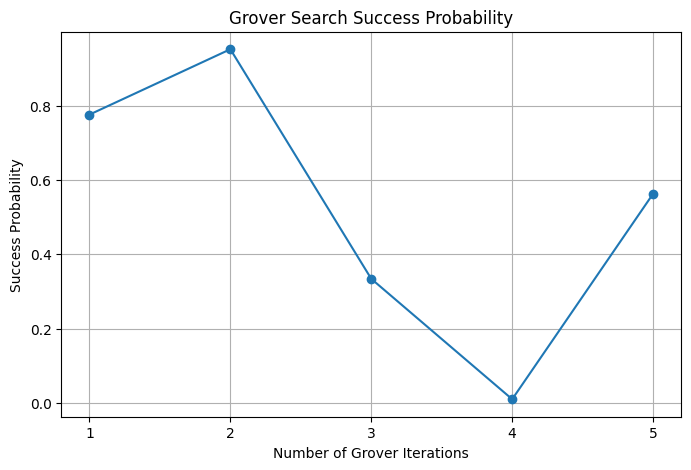

In [10]:
# 3-BIT VERSION

PASSWORD = "101"

# Create three qubits

q0 = cirq.GridQubit(0, 0)
q1 = cirq.GridQubit(0, 1)
q2 = cirq.GridQubit(0, 2)

qubits = [q0, q1, q2]

# Oracle
# Marks the correct password with a phase flip

def oracle(circuit, qubits, password):

    # Flip qubits that correspond to 0 bits
    for i, bit in enumerate(password):
        if bit == "0":
            circuit.append(cirq.X(qubits[i]))

    # Multi-controlled Z
    circuit.append(cirq.H(qubits[2]))
    circuit.append(cirq.CCX(qubits[0], qubits[1], qubits[2]))
    circuit.append(cirq.H(qubits[2]))

    # Undo temporary X gates
    for i, bit in enumerate(password):
        if bit == "0":
            circuit.append(cirq.X(qubits[i]))

# Diffusion Operator

def diffusion(circuit, qubits):

    circuit.append(cirq.H.on_each(*qubits))
    circuit.append(cirq.X.on_each(*qubits))

    circuit.append(cirq.H(qubits[2]))
    circuit.append(cirq.CCX(qubits[0], qubits[1], qubits[2]))
    circuit.append(cirq.H(qubits[2]))

    circuit.append(cirq.X.on_each(*qubits))
    circuit.append(cirq.H.on_each(*qubits))

# Build Grover Circuit

def build_circuit(password, iterations):

    circuit = cirq.Circuit()

    # Equal superposition
    circuit.append(cirq.H.on_each(*qubits))

    # Grover iterations
    for _ in range(iterations):
        oracle(circuit, qubits, password)
        diffusion(circuit, qubits)

    # Measure
    circuit.append(cirq.measure(*qubits, key="result"))

    return circuit

# Run one experiment

def run_experiment(password, iterations, repetitions):

    simulator = cirq.Simulator()

    circuit = build_circuit(password, iterations)

    results = simulator.run(circuit, repetitions=repetitions)

    histogram = results.histogram(key="result")

    target = int(password, 2)

    success = histogram.get(target, 0)

    probability = success / repetitions

    return probability, histogram, circuit

# Multiple Trials

repetitions = 1000
max_iterations = 5

success_rates = []

for iterations in range(1, max_iterations + 1):

    probability, histogram, circuit = run_experiment(
        PASSWORD,
        iterations,
        repetitions
    )

    success_rates.append(probability)

    print("\n===================================")
    print(f"Iterations: {iterations}")
    print(f"Success Probability: {probability:.4f}")
    print("Measurement Histogram:")
    print(histogram)

# Display the final circuit

print("\nFinal Circuit")
print(circuit)

# Plot Success Probability

plt.figure(figsize=(8,5))
plt.plot(
    range(1, max_iterations + 1),
    success_rates,
    marker="o"
)

plt.title("Grover Search Success Probability")
plt.xlabel("Number of Grover Iterations")
plt.ylabel("Success Probability")
plt.xticks(range(1, max_iterations + 1))
plt.grid(True)

plt.show()